In [1]:
import cfe
import scanpy as sc

cfe.settings.backend = "python_function"
cfe.logger.setLevel("DEBUG")

[2025年02月27日 20时18分54秒] INFO                                                                                 
                                          _____     _ _ ______    _       ______            _                      
                                         / ____|   | | |  ____|  | |     |  ____|          | |                     
                                        | |     ___| | | |__ __ _| |_ ___| |__  __  ___ __ | | ___  _ __ ___ _ __  
                                        | |    / _ \ | |  __/ _` | __/ _ \  __| \ \/ / '_ \| |/ _ \| '__/ _ \ '__| 
                                        | |___|  __/ | | | | (_| | ||  __/ |____ >  <| |_) | | (_) | | |  __/ |    
                                         \_____\___|_|_|_|  \__,_|\__\___|______/_/\_\ .__/|_|\___/|_|  \___|_|    
                                                                                     | |                           
                                                                              

数据

In [2]:
# 读取scvelo的pancreas数据
adata = sc.read_h5ad("/home/huang/PyCode/scRNA/data/Pancreas/endocrinogenesis_day15.h5ad")
fadata = cfe.data.FateAnnData.from_anndata(adata)
fadata.layers["expression"] = fadata.layers["spliced"]
fadata.layers["count"] = fadata.layers["spliced"]

basis = "umap"

sc.pp.subsample(fadata, n_obs=500)

fadata

                        DEBUG    Create a FateAnnData object from an existing AnnData object.                      
                        DEBUG    Create a FateAnnData object from an existing AnnData object.                      


/home/huang/.conda/envs/cfe/lib/python3.10/site-packages/anndata/compat/__init__.py:358: FutureWarning: Moving element from .uns['neighbors']['distances'] to .obsp['distances'].

This is where adjacency matrices should go now.
  warn(
/home/huang/.conda/envs/cfe/lib/python3.10/site-packages/anndata/compat/__init__.py:358: FutureWarning: Moving element from .uns['neighbors']['connectivities'] to .obsp['connectivities'].

This is where adjacency matrices should go now.
  warn(


AnnData object with n_obs × n_vars = 500 × 27998
    obs: 'clusters_coarse', 'clusters', 'S_score', 'G2M_score'
    var: 'highly_variable_genes'
    uns: 'clusters_coarse_colors', 'clusters_colors', 'day_colors', 'neighbors', 'pca', 'cfe'
    obsm: 'X_pca', 'X_umap'
    layers: 'spliced', 'unspliced', 'expression', 'count'

In [3]:
import pandas as pd

# 手动添加参考里程碑
milestone_network = pd.DataFrame(
    data=[
        ["Ductal", "Ngn3 low EP"],
        ["Ngn3 low EP", "Ngn3 high EP"],
        ["Ngn3 high EP", "Pre-endocrine"],
        ["Pre-endocrine", "Alpha"],
        ["Pre-endocrine", "Beta"],
        ["Pre-endocrine", "Delta"],
        ["Pre-endocrine", "Epsilon"],
        ],
    columns=["from", "to"]
)

fadata.add_trajectory_mannually(milestone_network)

                        DEBUG    FateAnnData add_trajectory                                                        


/home/huang/PyCode/scRNA/CellFateExplorer/CellFateExplorer/cfe/data/fate_anndata.py:261: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  milestone_emb = np.array(list(obs.groupby(cluster_key).apply(lambda x: X_emb[list(x.index)].mean(axis=0))))


[2025年02月27日 20时18分55秒] DEBUG    plot_trajectory                                                             
[2025年02月27日 20时18分56秒] DEBUG    add waypoints                                                               
                        DEBUG    FateAnnData add_waypoints                                                         
                        DEBUG    add waypoints shape is (210, 500), finished!                                      


AnnData object with n_obs × n_vars = 500 × 27998
    obs: 'clusters_coarse', 'clusters', 'S_score', 'G2M_score', 'milestone_color', 'milestone'
    var: 'highly_variable_genes'
    uns: 'clusters_coarse_colors', 'clusters_colors', 'day_colors', 'neighbors', 'pca', 'cfe', 'milestone_colors', 'milestone_color_colors'
    obsm: 'X_pca', 'X_umap', 'milestone_network_emb'
    layers: 'spliced', 'unspliced', 'expression', 'count'

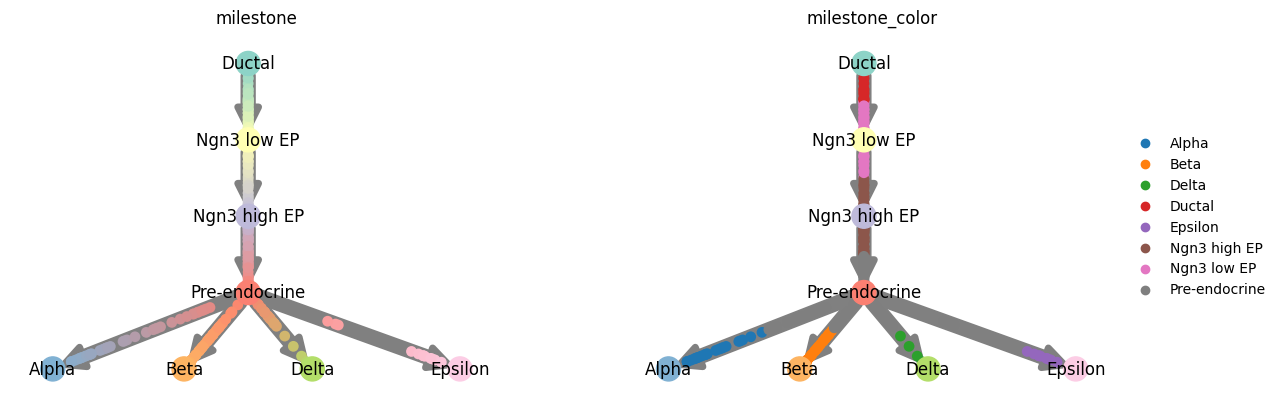

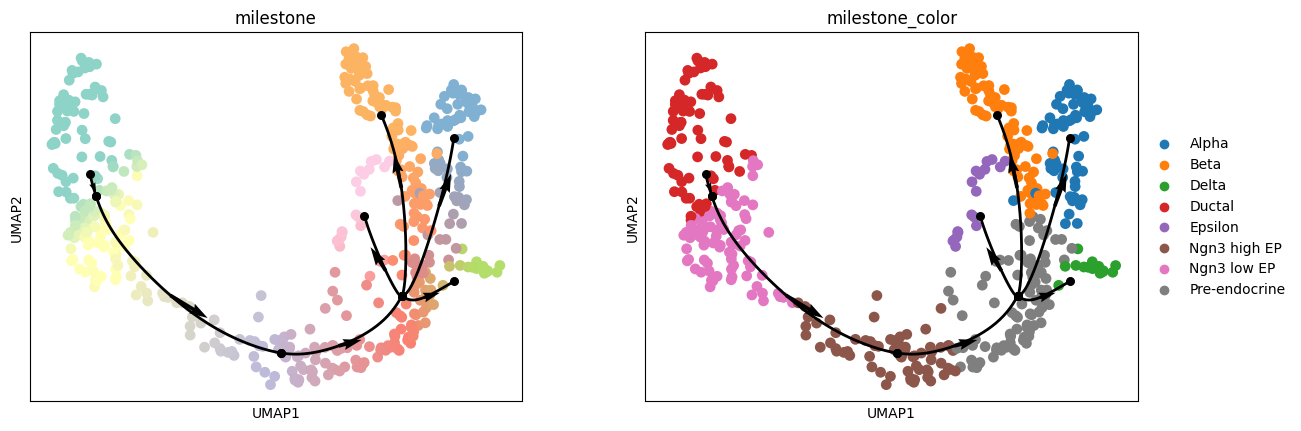

In [4]:
cluster_key = "milestone_color"
fadata.group_onto_nearest_milestones(cluster_key=cluster_key) # new cluster color

cluster_key_list = ["milestone", cluster_key]
cfe.plot.plot_graph(fadata, color=cluster_key_list)
cfe.plot.plot_trajectory(fadata, basis=basis, color=cluster_key_list)
fadata

Method and plot

[2025年02月27日 20时18分59秒] DEBUG    Docker image(dynverse/ti_slingshot:v1.0.3) loaded                           
                        INFO     method_backend: <cfe.method.fate_dynverse_docker_backend.DynverseDockerBackend    
                                 object at 0x763439ddbeb0>                                                         
                        WARNING                                                                                    
                                                 Prior information end_id,start_id is optional, but missing from   
                                 dataset 20250227_201854__FateAnnData__ZerGbBNHyh.                                 
                                                                                                                   
                                                 Will not give this prior to method.                               
                                                                              

<Axes: title={'center': 'milestone_color'}, xlabel='UMAP1', ylabel='UMAP2'>

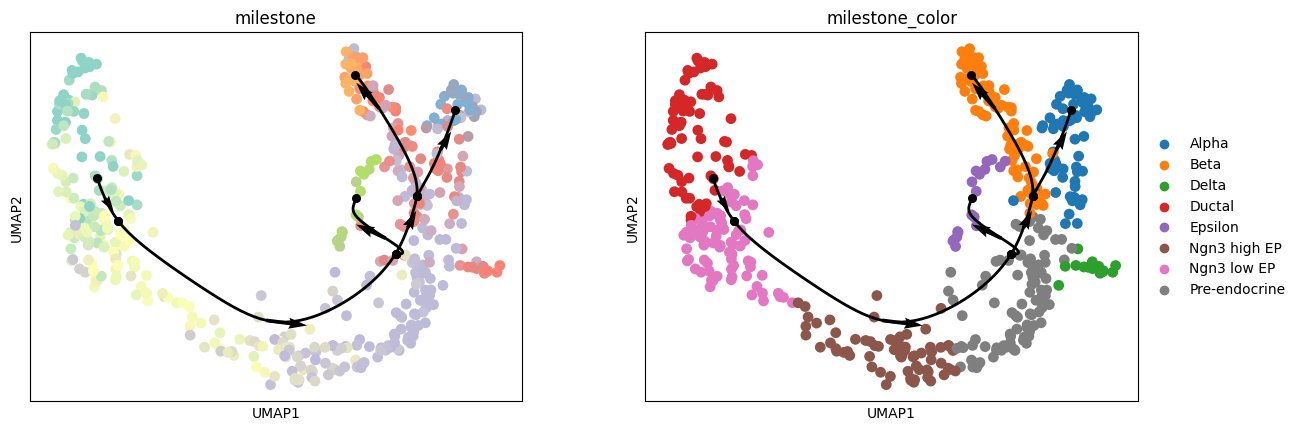

In [5]:
slingshot = cfe.method.FateMethod(method_name="slingshot", backend="dynverse_docker")

slingshot.infer_trajectory(fadata)

cfe.plot.plot_trajectory(fadata, basis=basis, color=cluster_key_list)

[2025年02月27日 20时19分42秒] DEBUG    FunctionBackend __init__                                                    
                        INFO     Loaded function: <function cf_paga at 0x76343fb92170> from                        
                                 /home/huang/PyCode/scRNA/CellFateExplorer/CellFateExplorer/cfe/method/function/cf_
                                 paga.py                                                                           
                        INFO     method_backend: <cfe.method.fate_function_backend.FunctionBackend object at       
                                 0x76344e298eb0>                                                                   
Normalized count data: X, spliced, unspliced.
Logarithmized X.


/home/huang/.conda/envs/cfe/lib/python3.10/site-packages/scvelo/preprocessing/utils.py:705: DeprecationWarning: `log1p` is deprecated since scVelo v0.3.0 and will be removed in a future version. Please use `log1p` from `scanpy.pp` instead.
  log1p(adata)


[2025年02月27日 20时19分46秒] DEBUG    FateAnnData add_trajectory_branch                                           
                        DEBUG    FateAnnData add_trajectory                                                        
                        DEBUG    plot_trajectory                                                                   


/home/huang/PyCode/scRNA/CellFateExplorer/CellFateExplorer/cfe/method/function/cf_paga.py:47: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  branches["length"] = adata.obs[[cluster_key, "dpt_pseudotime"]].groupby(cluster_key).apply(lambda x: x["dpt_pseudotime"].max() - x["dpt_pseudotime"].min() + epsilon).reset_index()[0]
/home/huang/PyCode/scRNA/CellFateExplorer/CellFateExplorer/cfe/data/fate_milestone_wrapper.py:130: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the 

                        DEBUG    add waypoints                                                                     
                        DEBUG    FateAnnData add_waypoints                                                         


/home/huang/PyCode/scRNA/CellFateExplorer/CellFateExplorer/cfe/data/fate_milestone_wrapper.py:130: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  froms = progressions.groupby(["cell_id", "from"]).apply(lambda x: 1- x["percentage"].sum()).rename().reset_index()


[2025年02月27日 20时19分47秒] DEBUG    add waypoints shape is (210, 500), finished!                                


/home/huang/PyCode/scRNA/CellFateExplorer/CellFateExplorer/cfe/data/fate_waypoint_wrapper.py:239: DeprecationWarning: Graph.shortest_paths() is deprecated; use Graph.distances() instead
  shortest_paths = gr.shortest_paths(source=waypoint_id_list, target=cell_id_list, weights="length", mode=mode)
/home/huang/PyCode/scRNA/CellFateExplorer/CellFateExplorer/cfe/data/fate_waypoint_wrapper.py:94: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda group: group.assign(
/home/huang/PyCode/scRNA/CellFateExplorer/CellFateExplorer/cfe/plot/plot_trajectory.py:155: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pand

<Axes: title={'center': 'milestone_color'}, xlabel='UMAP1', ylabel='UMAP2'>

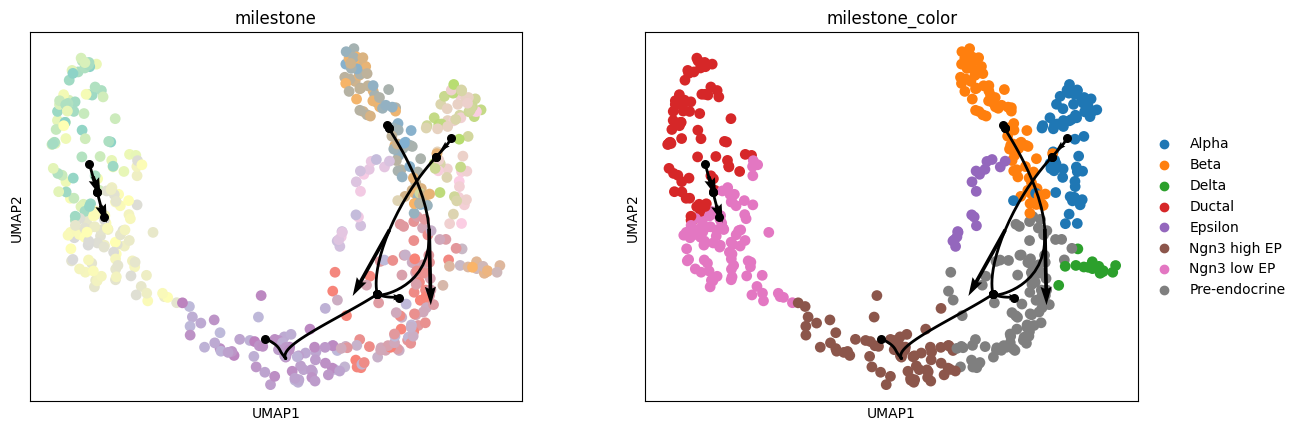

In [6]:
# TODO: PAGA need to be optimized, disconnected graph
paga_method = cfe.method.FateMethod(method_name="paga")

prior_information = {
    "start_id": fadata.obs.index[0],
    "groups_id": fadata.obs[cluster_key].tolist()
}
parameters = {"filter_features": False, "connectivity_cutoff": 0.3}
fadata.add_prior_information(**prior_information)  # add prior information to fadata
paga_method.infer_trajectory(fadata, parameters=parameters)

cfe.plot.plot_trajectory(fadata, basis=basis, color=cluster_key_list)

[2025年02月27日 20时19分49秒] DEBUG    FunctionBackend __init__                                                    
                        INFO     Loaded function: <function cf_comp1 at 0x76342a9ba7a0> from                       
                                 /home/huang/PyCode/scRNA/CellFateExplorer/CellFateExplorer/cfe/method/function/cf_
                                 comp1.py                                                                          
                        INFO     method_backend: <cfe.method.fate_function_backend.FunctionBackend object at       
                                 0x76342a82d840>                                                                   
                        DEBUG    FateAnnData add_trajectory                                                        
                        DEBUG    plot_trajectory                                                                   


/home/huang/PyCode/scRNA/CellFateExplorer/CellFateExplorer/cfe/data/fate_milestone_wrapper.py:130: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  froms = progressions.groupby(["cell_id", "from"]).apply(lambda x: 1- x["percentage"].sum()).rename().reset_index()
/home/huang/PyCode/scRNA/CellFateExplorer/CellFateExplorer/cfe/plot/add_color.py:32: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  cell_color_df = mil

                        DEBUG    add waypoints                                                                     
                        DEBUG    FateAnnData add_waypoints                                                         


/home/huang/PyCode/scRNA/CellFateExplorer/CellFateExplorer/cfe/data/fate_milestone_wrapper.py:130: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  froms = progressions.groupby(["cell_id", "from"]).apply(lambda x: 1- x["percentage"].sum()).rename().reset_index()


[2025年02月27日 20时19分50秒] DEBUG    add waypoints shape is (201, 500), finished!                                


/home/huang/PyCode/scRNA/CellFateExplorer/CellFateExplorer/cfe/data/fate_waypoint_wrapper.py:239: DeprecationWarning: Graph.shortest_paths() is deprecated; use Graph.distances() instead
  shortest_paths = gr.shortest_paths(source=waypoint_id_list, target=cell_id_list, weights="length", mode=mode)
/home/huang/PyCode/scRNA/CellFateExplorer/CellFateExplorer/cfe/data/fate_waypoint_wrapper.py:94: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda group: group.assign(
/home/huang/PyCode/scRNA/CellFateExplorer/CellFateExplorer/cfe/plot/plot_trajectory.py:155: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pand

<Axes: title={'center': 'milestone_color'}, xlabel='UMAP1', ylabel='UMAP2'>

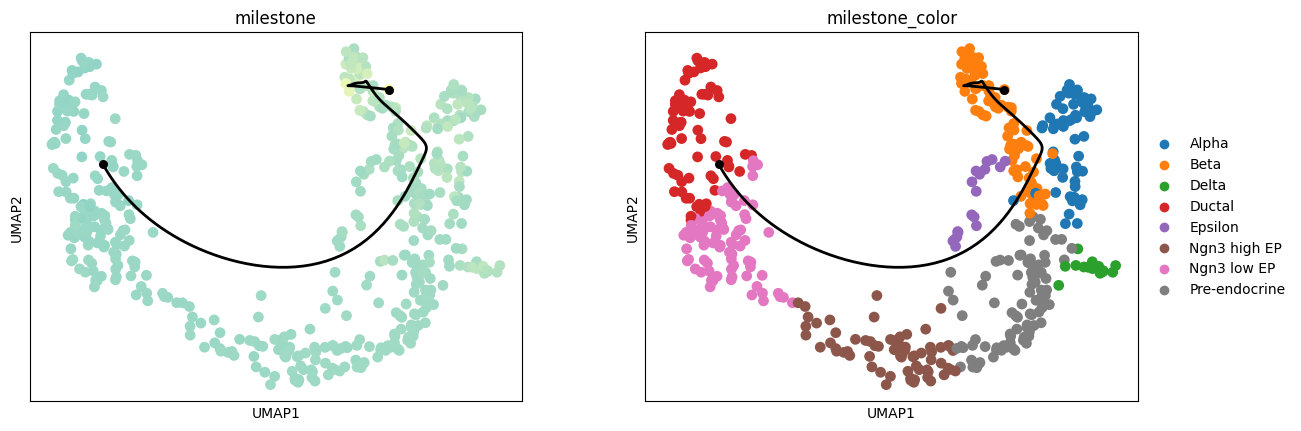

In [7]:
# Comp1
comp1_method = cfe.method.FateMethod(method_name="comp1")

comp1_method.infer_trajectory(fadata)

cfe.plot.plot_trajectory(fadata, basis=basis, color=cluster_key_list)

[2025年02月27日 20时19分55秒] DEBUG    FunctionBackend __init__                                                    
                        INFO     Loaded function: <function cf_state_comp at 0x763425b6c5e0> from                  
                                 /home/huang/PyCode/scRNA/CellFateExplorer/CellFateExplorer/cfe/method/function/cf_
                                 state_comp.py                                                                     
                        INFO     method_backend: <cfe.method.fate_function_backend.FunctionBackend object at       
                                 0x763448f130d0>                                                                   
                        DEBUG    FateAnnData add_trajectory                                                        
                        DEBUG    plot_trajectory                                                                   


/home/huang/PyCode/scRNA/CellFateExplorer/CellFateExplorer/cfe/data/fate_milestone_wrapper.py:130: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  froms = progressions.groupby(["cell_id", "from"]).apply(lambda x: 1- x["percentage"].sum()).rename().reset_index()
/home/huang/PyCode/scRNA/CellFateExplorer/CellFateExplorer/cfe/plot/add_color.py:32: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  cell_color_df = mil

[2025年02月27日 20时19分56秒] DEBUG    add waypoints                                                               
                        DEBUG    FateAnnData add_waypoints                                                         


/home/huang/PyCode/scRNA/CellFateExplorer/CellFateExplorer/cfe/data/fate_milestone_wrapper.py:130: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  froms = progressions.groupby(["cell_id", "from"]).apply(lambda x: 1- x["percentage"].sum()).rename().reset_index()


                        DEBUG    add waypoints shape is (202, 500), finished!                                      


/home/huang/PyCode/scRNA/CellFateExplorer/CellFateExplorer/cfe/data/fate_waypoint_wrapper.py:239: DeprecationWarning: Graph.shortest_paths() is deprecated; use Graph.distances() instead
  shortest_paths = gr.shortest_paths(source=waypoint_id_list, target=cell_id_list, weights="length", mode=mode)
/home/huang/PyCode/scRNA/CellFateExplorer/CellFateExplorer/cfe/data/fate_waypoint_wrapper.py:94: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda group: group.assign(
/home/huang/PyCode/scRNA/CellFateExplorer/CellFateExplorer/cfe/plot/plot_trajectory.py:155: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pand

<Axes: title={'center': 'milestone_color'}, xlabel='UMAP1', ylabel='UMAP2'>

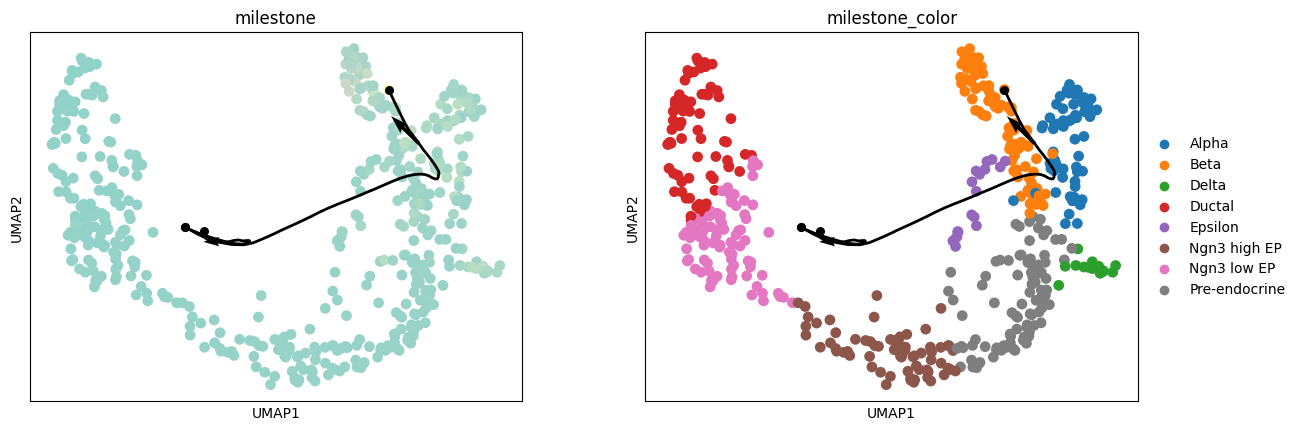

In [ ]:
# state_comp
state_comp = cfe.method.FateMethod(method_name="state_comp")

state_comp.infer_trajectory(fadata)

cfe.plot.plot_trajectory(fadata, basis=basis, color=cluster_key_list)

[2025年02月27日 20时19分52秒] DEBUG    FunctionBackend __init__                                                    
                        INFO     Loaded function: <function cf_cluster_mst at 0x76342a9ba560> from                 
                                 /home/huang/PyCode/scRNA/CellFateExplorer/CellFateExplorer/cfe/method/function/cf_
                                 cluster_mst.py                                                                    
                        INFO     method_backend: <cfe.method.fate_function_backend.FunctionBackend object at       
                                 0x76342a82f790>                                                                   
                        DEBUG    FateAnnData add_trajectory                                                        
                        DEBUG    plot_trajectory                                                                   


/home/huang/PyCode/scRNA/CellFateExplorer/CellFateExplorer/cfe/method/function/cf_cluster_mst.py:36: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  centers = np.array(list(adata.obs.groupby(cluster_key).apply(lambda x: X_emb[list(x.index)].mean(axis=0))))
/home/huang/PyCode/scRNA/CellFateExplorer/CellFateExplorer/cfe/data/fate_anndata.py:512: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: x.s

[2025年02月27日 20时19分53秒] DEBUG    add waypoints                                                               
                        DEBUG    FateAnnData add_waypoints                                                         


/home/huang/PyCode/scRNA/CellFateExplorer/CellFateExplorer/cfe/data/fate_milestone_wrapper.py:130: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  froms = progressions.groupby(["cell_id", "from"]).apply(lambda x: 1- x["percentage"].sum()).rename().reset_index()


                        DEBUG    add waypoints shape is (210, 500), finished!                                      


/home/huang/PyCode/scRNA/CellFateExplorer/CellFateExplorer/cfe/data/fate_waypoint_wrapper.py:239: DeprecationWarning: Graph.shortest_paths() is deprecated; use Graph.distances() instead
  shortest_paths = gr.shortest_paths(source=waypoint_id_list, target=cell_id_list, weights="length", mode=mode)
/home/huang/PyCode/scRNA/CellFateExplorer/CellFateExplorer/cfe/data/fate_waypoint_wrapper.py:94: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda group: group.assign(
/home/huang/PyCode/scRNA/CellFateExplorer/CellFateExplorer/cfe/plot/plot_trajectory.py:155: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pand

<Axes: title={'center': 'milestone_color'}, xlabel='UMAP1', ylabel='UMAP2'>

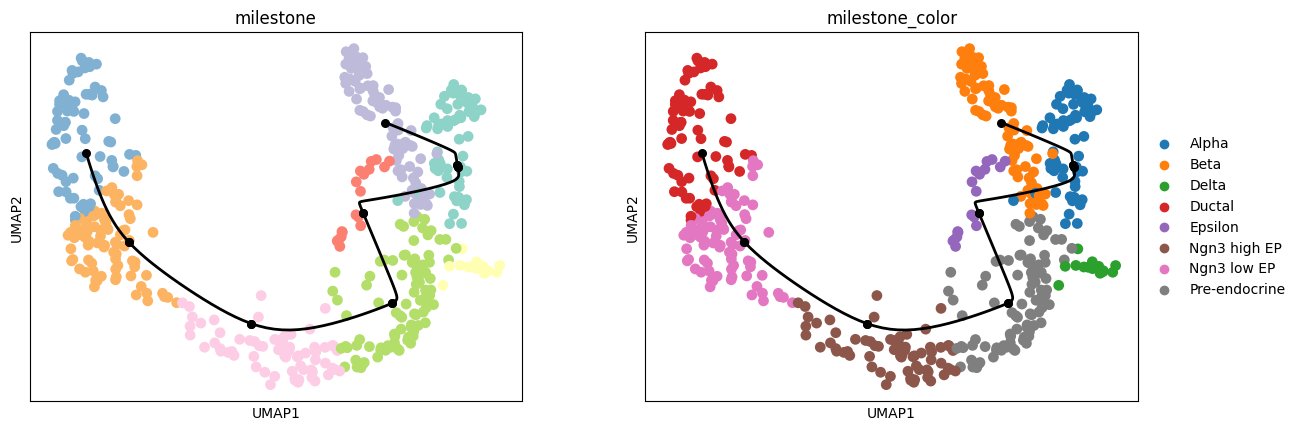

In [ ]:
# cluster_mst
cluster_mst = cfe.method.FateMethod(method_name="cluster_mst")

cluster_mst.infer_trajectory(fadata)

cfe.plot.plot_trajectory(fadata, basis=basis, color=cluster_key_list)

[2025年02月27日 20时19分58秒] DEBUG    FunctionBackend __init__                                                    
                        INFO     Loaded function: <function cf_mst at 0x76342404e290> from                         
                                 /home/huang/PyCode/scRNA/CellFateExplorer/CellFateExplorer/cfe/method/function/cf_
                                 mst.py                                                                            
                        INFO     method_backend: <cfe.method.fate_function_backend.FunctionBackend object at       
                                 0x76343bf44ac0>                                                                   
                        DEBUG    FateAnnData add_trajectory                                                        
                        DEBUG    plot_trajectory                                                                   


/home/huang/PyCode/scRNA/CellFateExplorer/CellFateExplorer/cfe/method/function/cf_mst.py:45: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  centers = np.array(list(adata.obs.groupby(cluster_key).apply(lambda x: X_emb[list(x.index)].mean(axis=0))))
/home/huang/PyCode/scRNA/CellFateExplorer/CellFateExplorer/cfe/data/fate_milestone_wrapper.py:130: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  froms = progressio

[2025年02月27日 20时19分59秒] DEBUG    add waypoints                                                               
                        DEBUG    FateAnnData add_waypoints                                                         


/home/huang/PyCode/scRNA/CellFateExplorer/CellFateExplorer/cfe/data/fate_milestone_wrapper.py:130: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  froms = progressions.groupby(["cell_id", "from"]).apply(lambda x: 1- x["percentage"].sum()).rename().reset_index()


                        DEBUG    add waypoints shape is (210, 500), finished!                                      


/home/huang/PyCode/scRNA/CellFateExplorer/CellFateExplorer/cfe/data/fate_waypoint_wrapper.py:239: DeprecationWarning: Graph.shortest_paths() is deprecated; use Graph.distances() instead
  shortest_paths = gr.shortest_paths(source=waypoint_id_list, target=cell_id_list, weights="length", mode=mode)
/home/huang/PyCode/scRNA/CellFateExplorer/CellFateExplorer/cfe/data/fate_waypoint_wrapper.py:94: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda group: group.assign(
/home/huang/PyCode/scRNA/CellFateExplorer/CellFateExplorer/cfe/plot/plot_trajectory.py:155: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pand

<Axes: title={'center': 'milestone_color'}, xlabel='UMAP1', ylabel='UMAP2'>

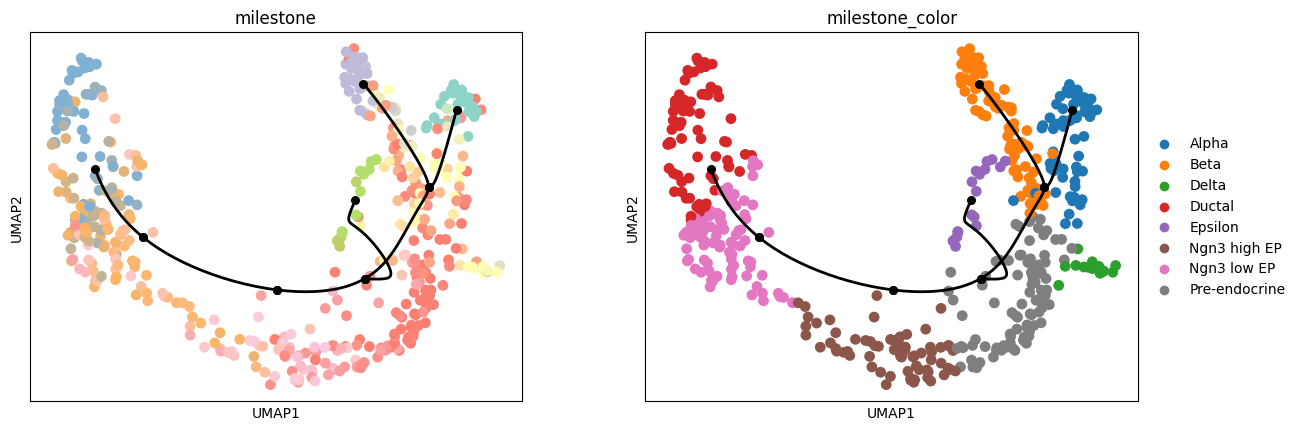

In [10]:
# TODO: MST need to be optimized
mst_method = cfe.method.FateMethod(method_name="mst", backend="python_function")

prior_information = {
    "groups_id": fadata.obs[cluster_key].tolist()
}
fadata.add_prior_information(**prior_information)  # add prior information to fadata

mst_method.infer_trajectory(fadata)

cfe.plot.plot_trajectory(fadata, basis=basis, color=cluster_key_list)

[2025年02月27日 20时20分01秒] DEBUG    FunctionBackend __init__                                                    
                        INFO     Loaded function: <function cf_scvelo at 0x7634143b9630> from                      
                                 /home/huang/PyCode/scRNA/CellFateExplorer/CellFateExplorer/cfe/method/function/cf_
                                 scvelo.py                                                                         
                        INFO     method_backend: <cfe.method.fate_function_backend.FunctionBackend object at       
                                 0x763425bd95d0>                                                                   
Filtered out 24737 genes that are detected 20 counts (shared).
Normalized count data: X, spliced, unspliced.
Extracted 2000 highly variable genes.
Logarithmized X.
computing neighbors


/home/huang/.conda/envs/cfe/lib/python3.10/site-packages/scvelo/preprocessing/utils.py:705: DeprecationWarning: `log1p` is deprecated since scVelo v0.3.0 and will be removed in a future version. Please use `log1p` from `scanpy.pp` instead.
  log1p(adata)
/home/huang/PyCode/scRNA/CellFateExplorer/CellFateExplorer/cfe/method/function/cf_scvelo.py:21: DeprecationWarning: Automatic neighbor calculation is deprecated since scvelo==0.4.0 and will be removed in a future version of scVelo. Please compute neighbors first with Scanpy.
  scv.pp.moments(adata, n_pcs=30, n_neighbors=30)
/home/huang/.conda/envs/cfe/lib/python3.10/site-packages/scvelo/preprocessing/moments.py:71: DeprecationWarning: `neighbors` is deprecated since scvelo==0.4.0 and will be removed in a future version of scVelo. Please compute neighbors with Scanpy.
  neighbors(
/home/huang/.conda/envs/cfe/lib/python3.10/site-packages/scvelo/preprocessing/neighbors.py:233: DeprecationWarning: Automatic computation of PCA is deprecated

    finished (0:00:00) --> added 
    'distances' and 'connectivities', weighted adjacency matrices (adata.obsp)
computing moments based on connectivities
    finished (0:00:00) --> added 
    'Ms' and 'Mu', moments of un/spliced abundances (adata.layers)
computing velocities
    finished (0:00:00) --> added 
    'velocity', velocity vectors for each individual cell (adata.layers)
computing velocity graph (using 1/24 cores)


/home/huang/.conda/envs/cfe/lib/python3.10/site-packages/scvelo/tools/optimization.py:184: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  gamma[i] = np.linalg.pinv(A.T.dot(A)).dot(A.T.dot(y[:, i]))


  0%|          | 0/500 [00:00<?, ?cells/s]

...

                        DEBUG    add waypoints                                                                     
                        DEBUG    FateAnnData add_waypoints                                                         


/home/huang/PyCode/scRNA/CellFateExplorer/CellFateExplorer/cfe/data/fate_milestone_wrapper.py:130: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  froms = progressions.groupby(["cell_id", "from"]).apply(lambda x: 1- x["percentage"].sum()).rename().reset_index()


[2025年02月27日 20时20分03秒] DEBUG    add waypoints shape is (210, 500), finished!                                


/home/huang/PyCode/scRNA/CellFateExplorer/CellFateExplorer/cfe/data/fate_waypoint_wrapper.py:239: DeprecationWarning: Graph.shortest_paths() is deprecated; use Graph.distances() instead
  shortest_paths = gr.shortest_paths(source=waypoint_id_list, target=cell_id_list, weights="length", mode=mode)
/home/huang/PyCode/scRNA/CellFateExplorer/CellFateExplorer/cfe/data/fate_waypoint_wrapper.py:94: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda group: group.assign(
/home/huang/PyCode/scRNA/CellFateExplorer/CellFateExplorer/cfe/plot/plot_trajectory.py:155: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pand

<Axes: title={'center': 'milestone_color'}, xlabel='UMAP1', ylabel='UMAP2'>

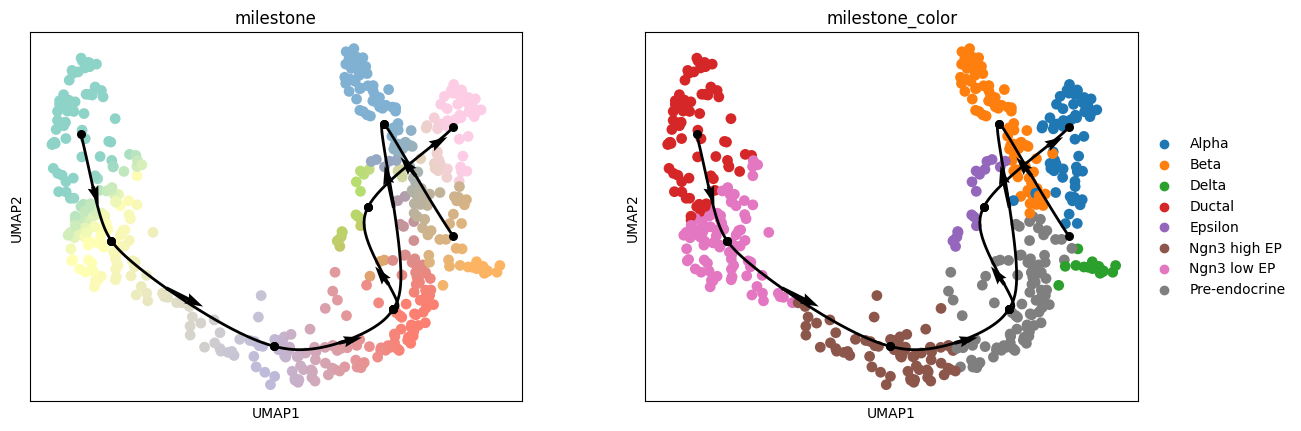

In [11]:
# scvelo

scvelo_method = cfe.method.FateMethod(method_name="scvelo", backend="python_function")

scvelo_method.infer_trajectory(fadata)

cfe.plot.plot_trajectory(fadata, basis=basis, color=cluster_key_list)

[2025年02月27日 20时20分05秒] DEBUG    FunctionBackend __init__                                                    
                        INFO     Loaded function: <function cf_cell_mst at 0x76342404f130> from                    
                                 /home/huang/PyCode/scRNA/CellFateExplorer/CellFateExplorer/cfe/method/function/cf_
                                 cell_mst.py                                                                       
                        INFO     method_backend: <cfe.method.fate_function_backend.FunctionBackend object at       
                                 0x76342510f6a0>                                                                   
                        DEBUG    FateAnnData add_trajectory                                                        


/home/huang/PyCode/scRNA/CellFateExplorer/CellFateExplorer/cfe/data/fate_milestone_wrapper.py:130: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  froms = progressions.groupby(["cell_id", "from"]).apply(lambda x: 1- x["percentage"].sum()).rename().reset_index()


[2025年02月27日 20时20分06秒] DEBUG    FateAnnData add_trajectory                                                  
                        DEBUG    plot_trajectory                                                                   
                        WARNING  The number of colors(260) is greater than the number of colors in the 'Set3'      
                                 palette(12), and the 'husl' palette selection is used.                            


/home/huang/PyCode/scRNA/CellFateExplorer/CellFateExplorer/cfe/data/fate_milestone_wrapper.py:130: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  froms = progressions.groupby(["cell_id", "from"]).apply(lambda x: 1- x["percentage"].sum()).rename().reset_index()
/home/huang/PyCode/scRNA/CellFateExplorer/CellFateExplorer/cfe/data/fate_milestone_wrapper.py:130: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  froms

[2025年02月27日 20时20分07秒] DEBUG    add waypoints                                                               
                        DEBUG    FateAnnData add_waypoints                                                         


/home/huang/PyCode/scRNA/CellFateExplorer/CellFateExplorer/cfe/data/fate_milestone_wrapper.py:130: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  froms = progressions.groupby(["cell_id", "from"]).apply(lambda x: 1- x["percentage"].sum()).rename().reset_index()


[2025年02月27日 20时20分11秒] DEBUG    add waypoints shape is (656, 500), finished!                                


/home/huang/PyCode/scRNA/CellFateExplorer/CellFateExplorer/cfe/data/fate_waypoint_wrapper.py:239: DeprecationWarning: Graph.shortest_paths() is deprecated; use Graph.distances() instead
  shortest_paths = gr.shortest_paths(source=waypoint_id_list, target=cell_id_list, weights="length", mode=mode)
/home/huang/PyCode/scRNA/CellFateExplorer/CellFateExplorer/cfe/data/fate_waypoint_wrapper.py:94: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda group: group.assign(
/home/huang/PyCode/scRNA/CellFateExplorer/CellFateExplorer/cfe/plot/plot_trajectory.py:155: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pand

<Axes: title={'center': 'milestone_color'}, xlabel='UMAP1', ylabel='UMAP2'>

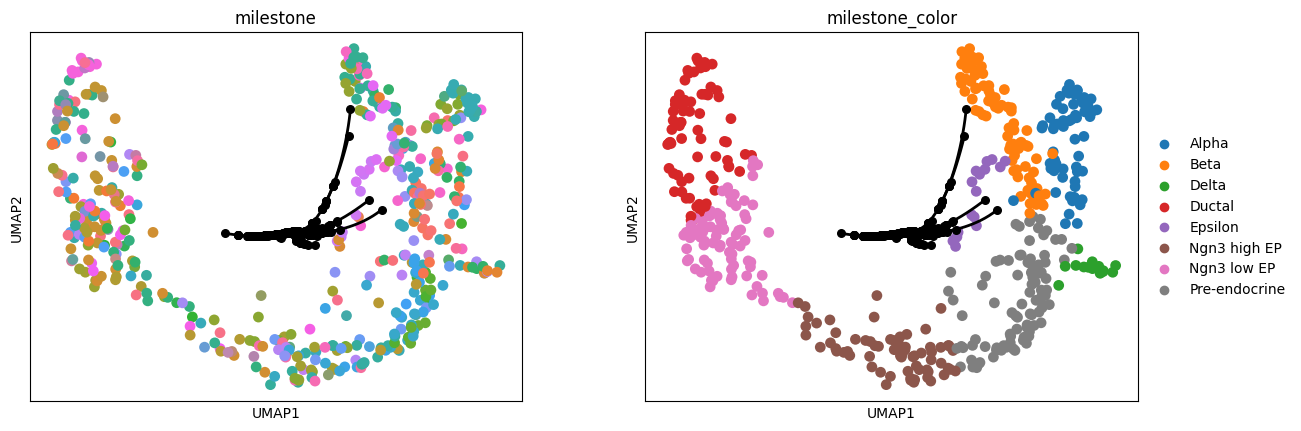

In [12]:
# cell_mst
cell_mst = cfe.method.FateMethod(method_name="cell_mst")

cell_mst.infer_trajectory(fadata)

cfe.plot.plot_trajectory(fadata, basis=basis, color=cluster_key_list)

## 指标

In [13]:
parsed_model_name_list = fadata.get_all_model_name()
model_name_list = fadata.get_all_model_name(parse=False)
parsed_model_name_list, model_name_list

[2025年02月27日 20时20分13秒] WARNING  'ref' is not a valid random_time_string, don't need parse                   


(['ref',
  'slingshot-dynverse_docker',
  'paga-python_function',
  'comp1-python_function',
  'cluster_mst-python_function',
  'state_comp-python_function',
  'mst-python_function',
  'scvelo-python_function',
  'cell_mst-python_function'],
 ['ref',
  '20250227_201859__slingshot-dynverse_docker__89tpbR1t5m',
  '20250227_201942__paga-python_function__ilZ4Uj4mRT',
  '20250227_201949__comp1-python_function__Q4igDVLzJs',
  '20250227_201952__cluster_mst-python_function__D2AuGiQLfN',
  '20250227_201955__state_comp-python_function__oGPAghzOhw',
  '20250227_201958__mst-python_function__DDyCv5GGo3',
  '20250227_202001__scvelo-python_function__2611pOysBG',
  '20250227_202005__cell_mst-python_function__Laso3nWgvE'])

In [14]:
metrics = cfe.metric.metrics
metric_id_list = metrics[metrics["category"] == "topology"]["metric_id"].tolist()
metric_id_list

['edge_flip', 'him', 'isomorphic']

In [15]:
import pandas as pd


model_metric_dict = {}

for model_name in model_name_list:
    model_metric = cfe.metric.calculate_metrics(
        fadata,
        metrics=metric_id_list,
        now_model=model_name,
        ref_model="ref"
    )
    model_metric_dict[model_name] = model_metric

df = pd.DataFrame(model_metric_dict).T
df

/home/huang/PyCode/scRNA/CellFateExplorer/CellFateExplorer/cfe/data/fate_milestone_wrapper.py:130: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  froms = progressions.groupby(["cell_id", "from"]).apply(lambda x: 1- x["percentage"].sum()).rename().reset_index()
/home/huang/PyCode/scRNA/CellFateExplorer/CellFateExplorer/cfe/data/fate_milestone_wrapper.py:130: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  froms

,isomorphic,edge_flip,him
ref,1,0,0
20250227_201859__slingshot-dynverse_docker__89tpbR1t5m,0,0,0
20250227_201942__paga-python_function__ilZ4Uj4mRT,0,0,0
20250227_201949__comp1-python_function__Q4igDVLzJs,0,0,0
20250227_201952__cluster_mst-python_function__D2AuGiQLfN,0,0,0
20250227_201955__state_comp-python_function__oGPAghzOhw,0,0,0
20250227_201958__mst-python_function__DDyCv5GGo3,0,0,0
20250227_202001__scvelo-python_function__2611pOysBG,0,0,0
20250227_202005__cell_mst-python_function__Laso3nWgvE,0,0,0
